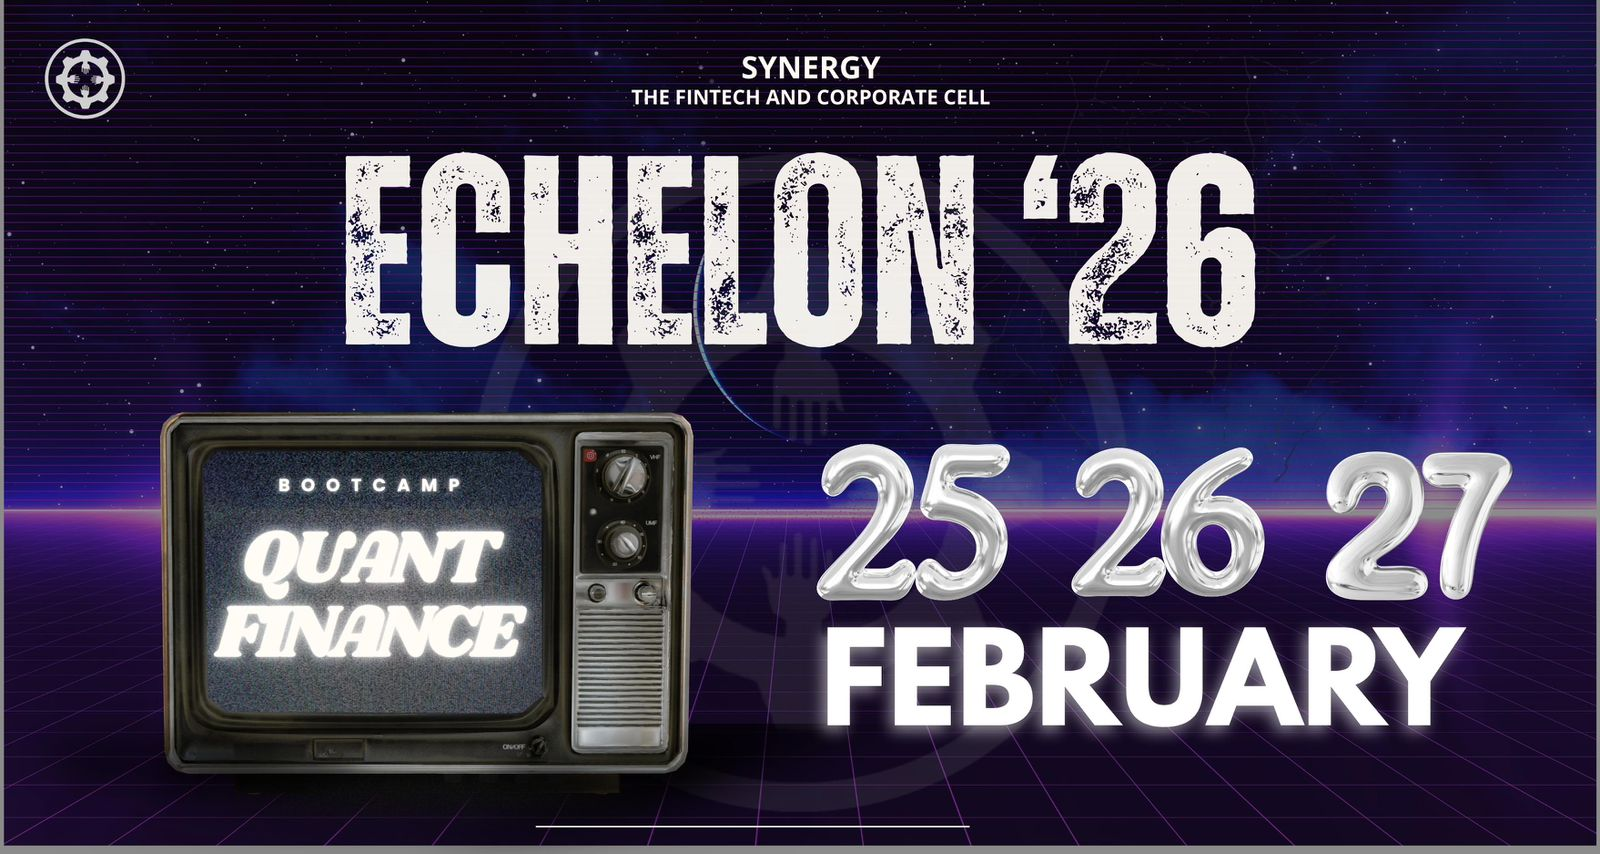

# Echelon'26 - Quantitative Finance Bootcamp  
## Day 1 - Financial Data, Returns & Distribution Analysis

---

# 1. Introduction

In quantitative finance, the fundamental object is **asset return**, not price.

Let:

$
P_t = \text{Price at time } t
$

## Simple Return

$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$

## Log Return

$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$

Log returns are preferred because:

- They are **time additive**:
$
r_{t,t+2} = r_{t,t+1} + r_{t+1,t+2}
$

- They simplify mathematical modeling.

---

We will:

1. Download financial data
2. Compute simple and log returns
3. Analyze distributions
4. Test normality
5. Study volatility clustering

In [24]:
# Install if needed
# !pip install yfinance scipy statsmodels

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")

In [25]:
# Download stock data
ticker = "AAPL"
data = yf.download(ticker, start="2018-01-01", end="2024-01-01")

print(data)

prices = data["Close"]
prices.head()   #use to preview the first 5 lines

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2018-01-02   40.304169   40.313530   39.602250   39.812828  102223600
2018-01-03   40.297153   40.839972   40.233983   40.367346  118071600
2018-01-04   40.484333   40.587282   40.262059   40.369685   89738400
2018-01-05   40.945259   41.031828   40.489013   40.580262   94640000
2018-01-08   40.793175   41.087979   40.694903   40.793175   82271200
...                ...         ...         ...         ...        ...
2023-12-22  191.609467  193.400854  190.985939  193.173208   37149600
2023-12-26  191.065125  191.896484  190.847385  191.619364   28919300
2023-12-27  191.164108  191.510516  189.125291  190.510906   48087700
2023-12-28  191.589661  192.658558  191.183873  192.143900   34049900
2023-12-29  190.550461  192.401229  189.758683  191.906370   42672100

[1509 rows x 5 colu

Ticker,AAPL
Date,
2018-01-02,40.304169
2018-01-03,40.297153
2018-01-04,40.484333
2018-01-05,40.945259
2018-01-08,40.793175


# 2. Computing Returns

We compute:

$
R_t = \frac{P_t}{P_{t-1}} - 1
$

$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$

In [26]:
simple_returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()
print(simple_returns)
print(log_returns)
#dropna is used to remove missing values (NaN)
#.shift(1) shifts the data down by 1 row

Ticker          AAPL
Date                
2018-01-03 -0.000174
2018-01-04  0.004645
2018-01-05  0.011385
2018-01-08 -0.003714
2018-01-09 -0.000115
...              ...
2023-12-22 -0.005548
2023-12-26 -0.002841
2023-12-27  0.000518
2023-12-28  0.002226
2023-12-29 -0.005424

[1508 rows x 1 columns]
Ticker          AAPL
Date                
2018-01-03 -0.000174
2018-01-04  0.004634
2018-01-05  0.011321
2018-01-08 -0.003721
2018-01-09 -0.000115
...              ...
2023-12-22 -0.005563
2023-12-26 -0.002845
2023-12-27  0.000518
2023-12-28  0.002224
2023-12-29 -0.005439

[1508 rows x 1 columns]


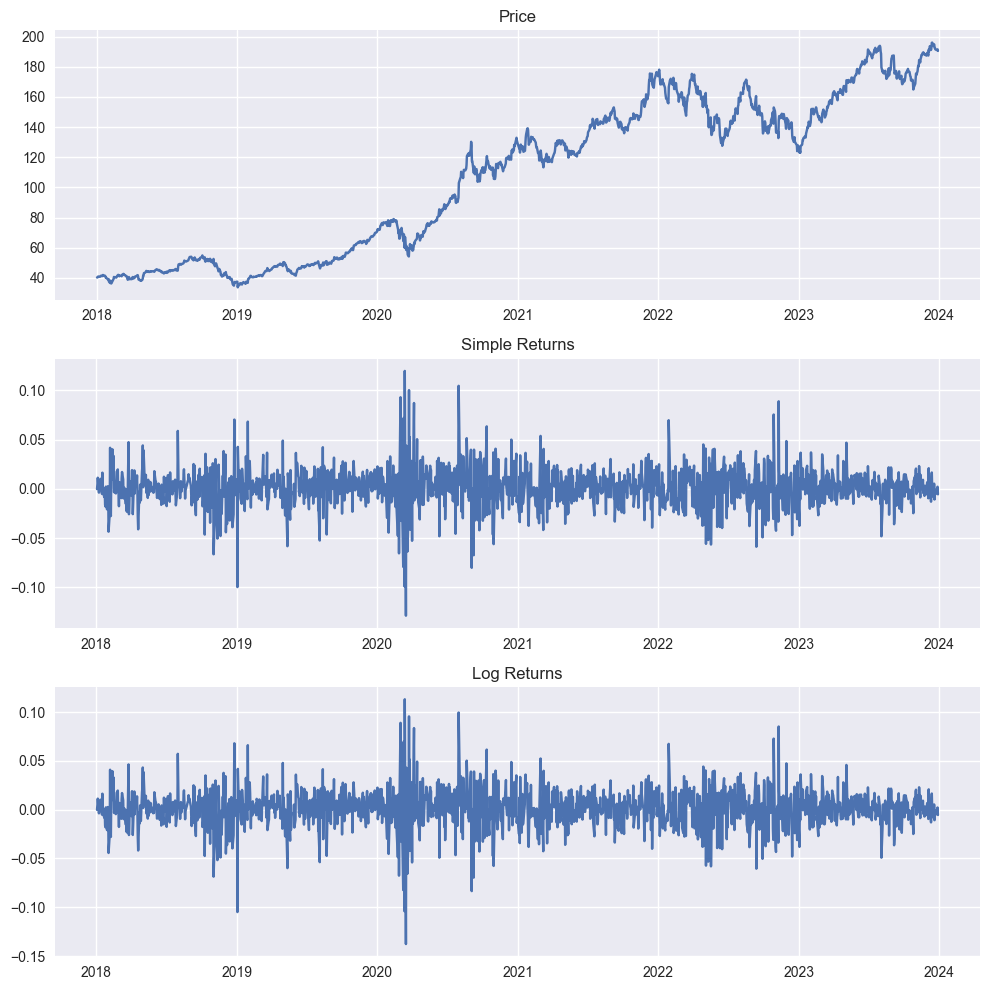

In [27]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

ax[0].plot(prices)
ax[0].set_title("Price")

ax[1].plot(simple_returns)
ax[1].set_title("Simple Returns")

ax[2].plot(log_returns)
ax[2].set_title("Log Returns")

plt.tight_layout()
plt.show()

#tight_layout = make the plot look clean and properly spaced

# 3. Distribution Analysis

If returns are normally distributed:

$
r_t \sim \mathcal{N}(\mu, \sigma^2)
$

Where:

- $\mu = \mathbb{E}[r_t]$
- $\sigma^2 = \text{Var}(r_t)$

We test:

- Skewness
- Kurtosis
- Normality

In [28]:
mean = log_returns.mean()
std = log_returns.std()
skew = stats.skew(log_returns)
kurt = stats.kurtosis(log_returns)

print("Mean:", mean)    #in output 0.00103
print("Std Dev:", std)  #in output 0.019965
print("Skewness:", skew)
print("Excess Kurtosis:", kurt)

Mean: Ticker
AAPL    0.00103
dtype: float64
Std Dev: Ticker
AAPL    0.019965
dtype: float64
Skewness: [-0.24441302]
Excess Kurtosis: [5.05907113]


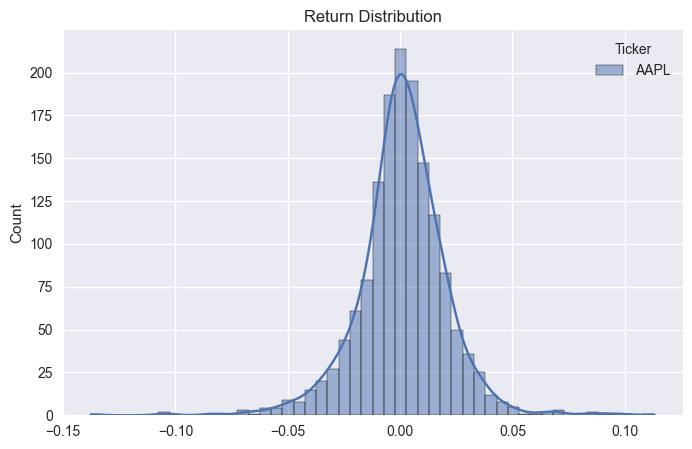

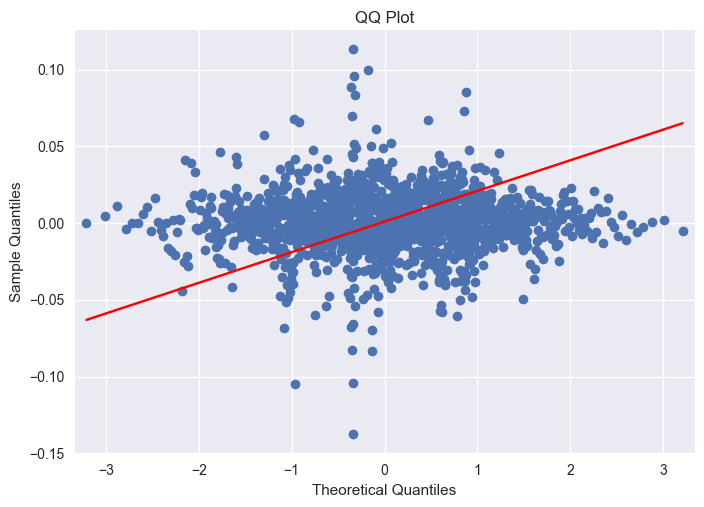

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(log_returns, bins=50, kde=True)
plt.title("Return Distribution")
plt.show()

sm.qqplot(log_returns, line='s')
plt.title("QQ Plot")
plt.show()

In [30]:
jb_test = stats.jarque_bera(log_returns)
print("Jarque-Bera Statistic:", jb_test.statistic)
print("p-value:", jb_test.pvalue)

Jarque-Bera Statistic: 1623.1830263389013
p-value: 0.0


# 4. Volatility Clustering

Volatility clustering means:

$
\text{High volatility periods tend to cluster together}
$

We analyze rolling volatility:

$
\sigma_t = \sqrt{\text{Var}(r_{t-k_{t}})}
$

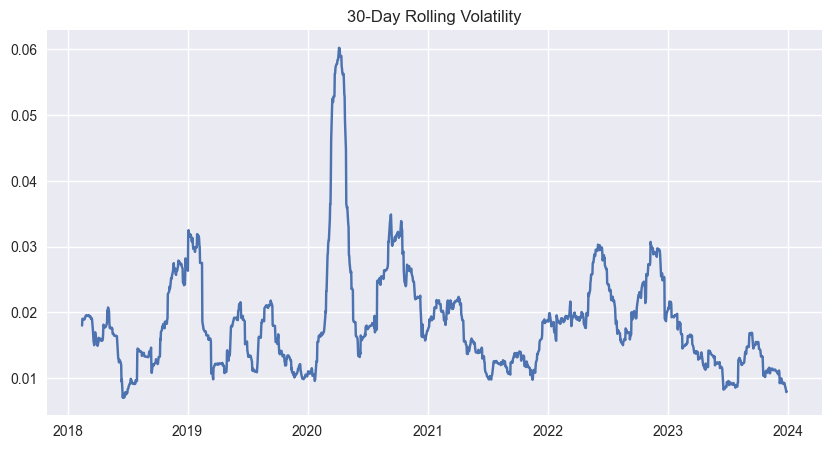

In [31]:
rolling_vol = log_returns.rolling(30).std()

plt.figure(figsize=(10,5))
plt.plot(rolling_vol)
plt.title("30-Day Rolling Volatility")
plt.show()